In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [85]:
df =  pd.read_csv("Titanic-Dataset.csv")

In [86]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [87]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [89]:
del df["Cabin"]

In [109]:
df["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [110]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

In [112]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [113]:
df["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [138]:
s = df["Age"].mean()
df["Age"].fillna(s)

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [139]:
df["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [190]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [175]:
survivors = (df[df["Survived"] == 1].groupby(["Sex","Pclass","Age"]).size())
non_survivors = (df[df["Survived"] == 0].groupby(["Sex","Pclass","Age"]).size())
print("survivors :\n",
      survivors)
print("non survivors :\n",
      non_survivors)

survivors :
 Sex     Pclass  Age 
female  1       14.0    1
                15.0    1
                16.0    3
                17.0    2
                18.0    3
                       ..
male    3       31.0    1
                32.0    5
                39.0    1
                44.0    1
                45.0    1
Length: 164, dtype: int64
non survivors :
 Sex     Pclass  Age 
female  1       2.0     1
                25.0    1
                50.0    1
        2       24.0    1
                26.0    1
                       ..
male    3       59.0    1
                61.0    1
                65.0    1
                70.5    1
                74.0    1
Length: 175, dtype: int64


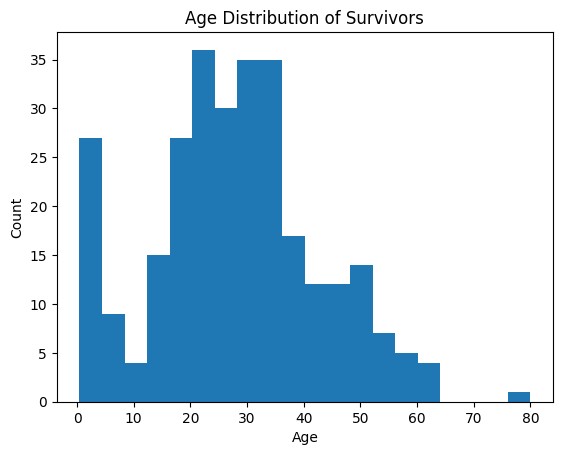

In [183]:
import matplotlib.pyplot as plt

# Filter survivors only
survivors = df[df['Survived'] == 1]

# Get counts grouped by Sex and Class
counts = survivors.groupby(['Sex','Pclass']).size().unstack()

# Plot as grouped histogram
survivors['Age'].plot(kind='hist', bins=20)
plt.title('Age Distribution of Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()



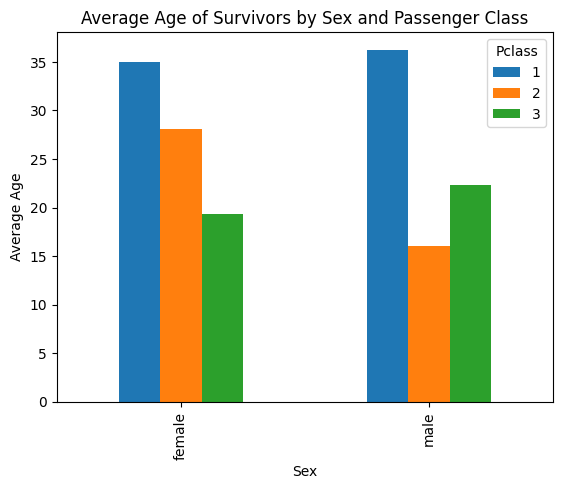

In [184]:
import matplotlib.pyplot as plt

# Filter survivors only
survivors = df[df['Survived'] == 1]

# Compute mean age grouped by Sex and Class
avg_age = survivors.groupby(['Sex','Pclass'])['Age'].mean().unstack()

# Plot as grouped bar chart
avg_age.plot(kind='bar')

plt.title('Average Age of Survivors by Sex and Passenger Class')
plt.ylabel('Average Age')
plt.xlabel('Sex')
plt.legend(title='Pclass')
plt.show()


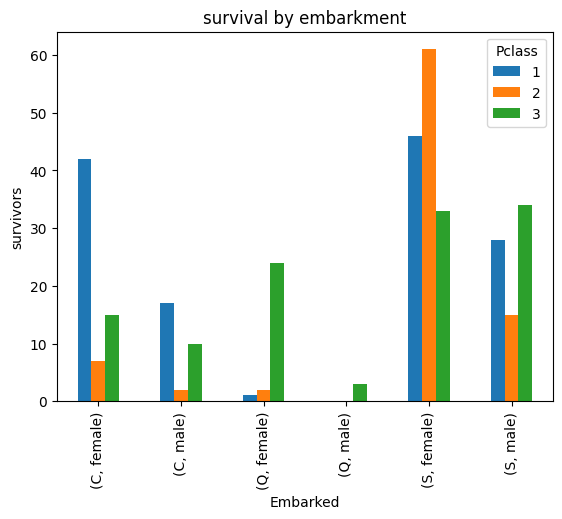

In [191]:
#survivors by embarkment
sur_emb = survivors.groupby(["Embarked","Sex","Pclass"]).size().unstack()

sur_emb.plot(kind = 'bar')
plt.title("survival by embarkment")
plt.ylabel('survivors')
plt.xlabel('Embarked')
plt.legend(title='Pclass')
plt.show()

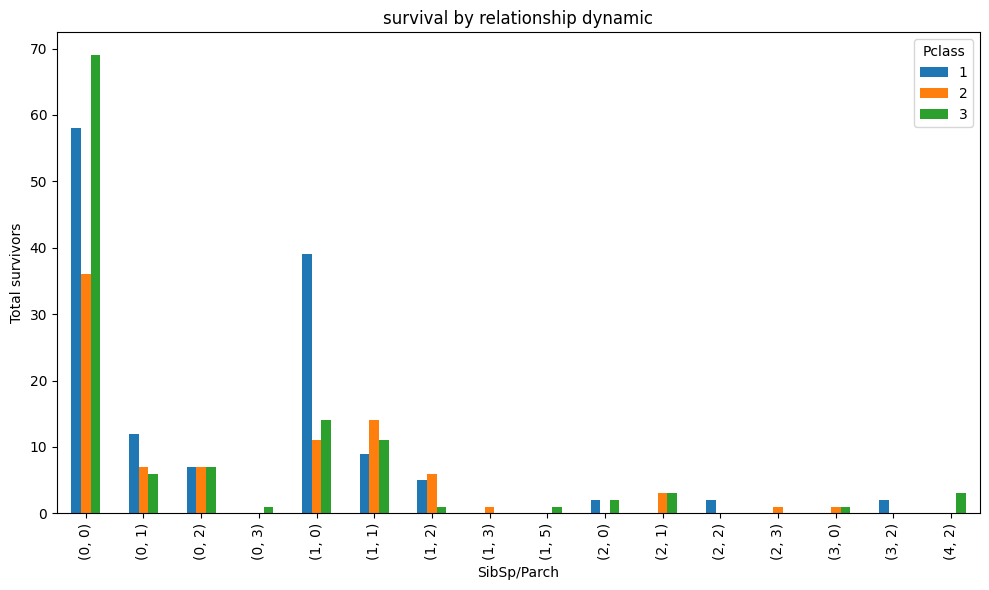

In [198]:
#survivors by relationship
sur_emb = survivors.groupby(["SibSp","Parch","Pclass"]).size().unstack()

sur_emb.plot(kind = 'bar',figsize=(10,6))
plt.title("survival by relationship dynamic")
plt.ylabel('Total survivors')
plt.xlabel('SibSp/Parch')
plt.legend(title='Pclass')
plt.tight_layout()
plt.show()